In [225]:
pip install ucimlrepo

In [226]:
from ucimlrepo import fetch_ucirepo
from scipy.linalg import svd
import scipy.stats as stats
import matplotlib.pyplot as plt
import importlib_resources
import seaborn as sns
import pandas as pd
import numpy as np
import xlrd

In [227]:

# fetch dataset
glass_identification = fetch_ucirepo(id=42)
df = glass_identification.data.features

# data (as pandas dataframes)
X = glass_identification.data.features.values
y_df = glass_identification.data.targets
y = glass_identification.data.targets.iloc[:, 0].values

classLabels = np.unique(y)
classNames = ["BW 1", "BW 2", "VW 1", "VW 2", "Containers", "Tableware", "Headlamps"]
attributeNames = df.columns
# Compute values of N, M and C.
N = len(y)
C = len(classNames)
M = len(attributeNames)

# Standarization
# means = np.mean(X, axis=0)  # mean of each column
# stds = np.std(X, axis=0)    # std deviation of each column

# Standardize each column
X = (X - X.mean(axis=0)) / X.std(axis=0)

# variable information
df.describe()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


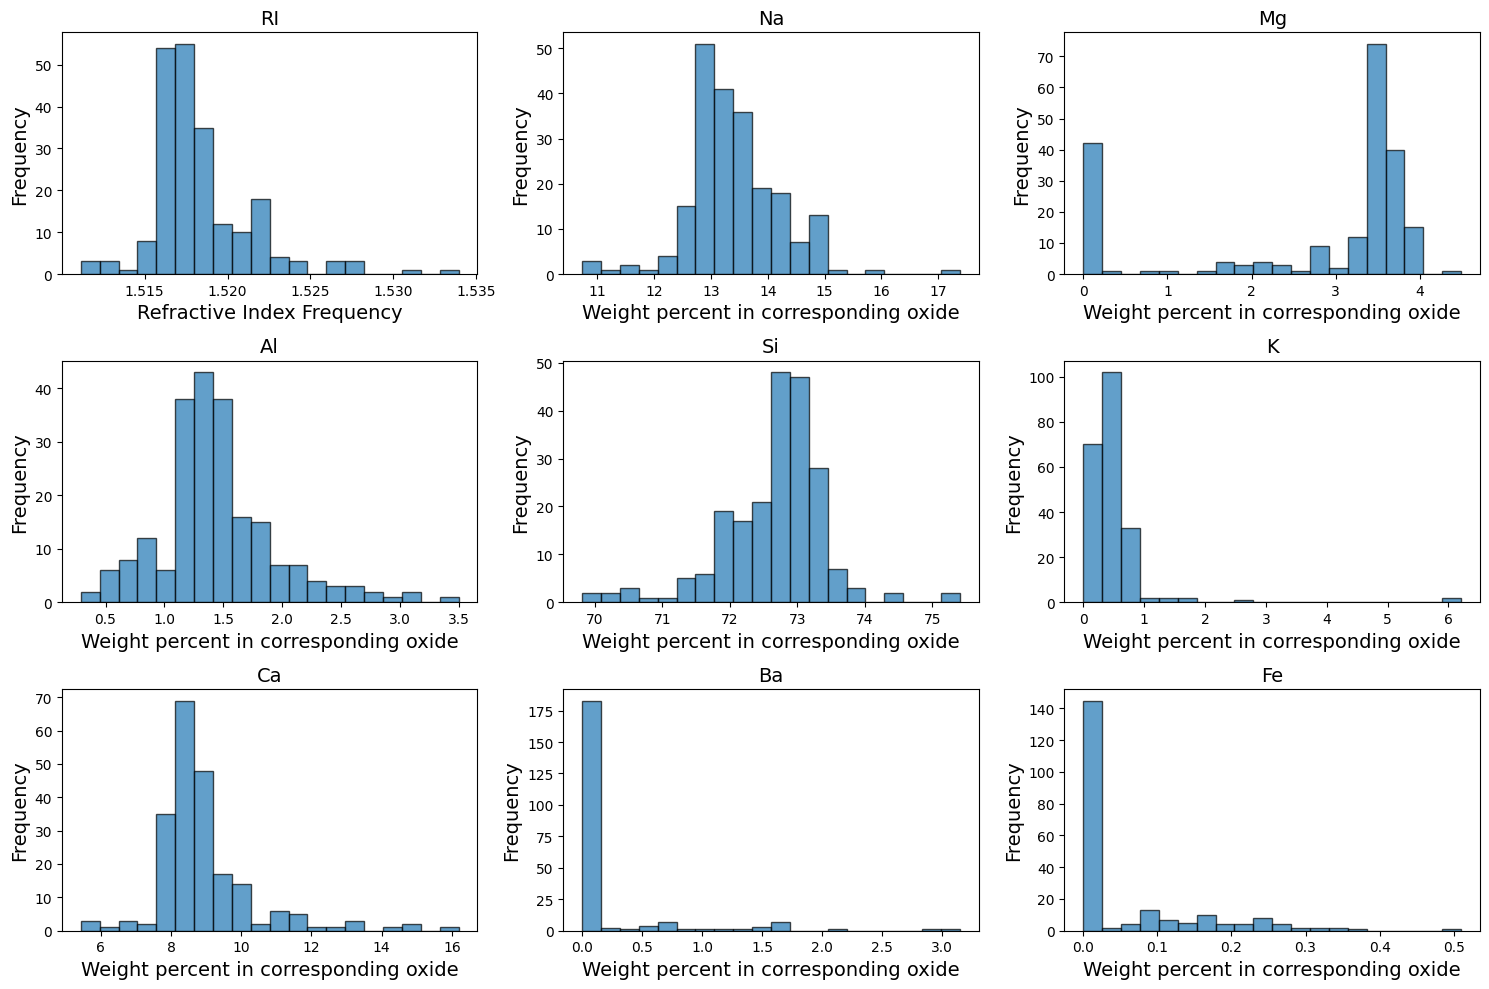

In [228]:
plt.figure(figsize=(15, 10))
# Loop through each feature and plot a histogram
for i, column in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)  # Adjust the grid size (3 rows, 4 columns) based on the number of features
    plt.hist(df[column], bins=20, edgecolor='black', alpha=0.7)
    plt.title(column,fontsize = 14)
    plt.ylabel("Frequency", fontsize = 14)
    # Customize y-label for RI
    if column == 'RI':
        plt.xlabel('Refractive Index Frequency', fontsize = 14)  # Custom y-label for RI
    else:
        plt.xlabel('Weight percent in corresponding oxide', fontsize = 14)  # Default y-label for other features
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

In [229]:
y_df['Type_of_glass'].value_counts()

,count
Type_of_glass,
2,76
1,70
7,29
3,17
5,13
6,9


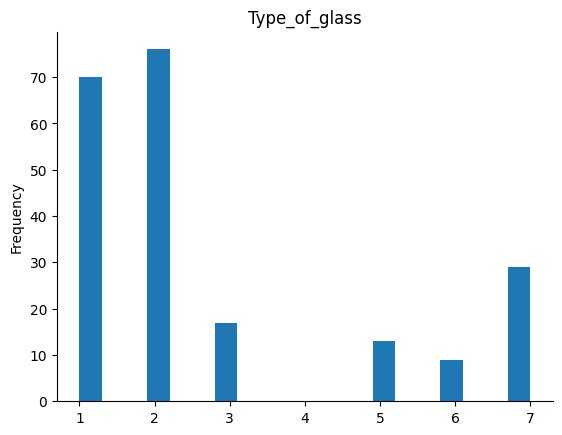

In [230]:
y_df['Type_of_glass'].plot(kind='hist', bins=20, title='Type_of_glass')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [231]:
X_standardized = (df - df.mean()) / df.std()

In [232]:
def add_jitter(x, scale=0.1):
    return x + np.random.uniform(-scale, scale, size=len(x))

In [233]:
df_standardized = (df - df.mean()) / df.std()


<ipython-input-234-0b0f75a36ab5>:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(X, labels=df.columns, whis=3)


Text(0, 0.5, 'Standardized Values')

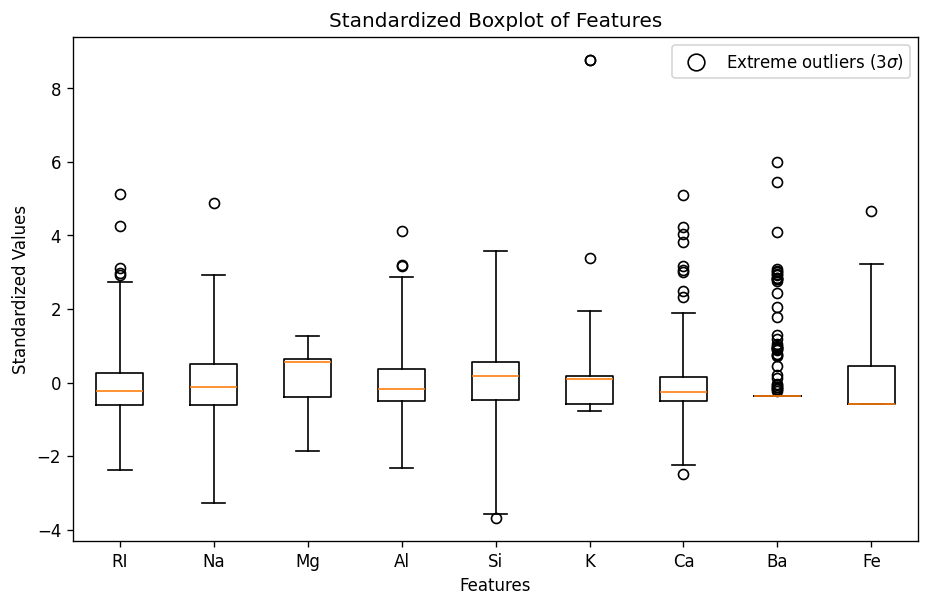

In [234]:
df_standardized["Class"] = y_df.iloc[:, 0].values  # Ensure correct assignment

# Melt the DataFrame into long format
df_melted = df_standardized.melt(id_vars=["Class"], var_name="Attribute", value_name="Value")

# Set figure size
plt.figure(figsize=(20, 12), dpi=120)

# First subplot: Strip plot
# plt.subplot(2, 2, 2)
# sns.stripplot(data=df_melted, x="Attribute", y="Value", hue="Class", palette="Set2", jitter=True, size=8)
# plt.xlabel("Attributes")
# plt.ylabel("Standardized Value")
# plt.title("Strip Plot of Glass Identification Dataset")
# plt.legend(title="Class", bbox_to_anchor=(1, 1))  # Move legend outside

# Second subplot: Box plot
plt.subplot(2, 2, 1)

# Plot boxplot and capture the return dictionary
boxplot = plt.boxplot(X, labels=df.columns, whis=3)

# Create a proxy artist (red outline circle) to represent outliers in the legend
outlier_proxy = plt.Line2D([], [], color='black', marker='o',
                          linestyle='none', markersize=10,
                          markerfacecolor='none', markeredgecolor='black',
                          label=r'Extreme outliers ($3\sigma$)')

# Add the legend
plt.legend(handles=[outlier_proxy], loc='upper right')

plt.title('Standardized Boxplot of Features')
plt.xlabel('Features')
plt.ylabel('Standardized Values')

In [235]:
K_sorted = np.sort(X[:, 5])
print(K_sorted[-4:-1])

[1.94100113 3.38567419 8.78014487]


In [236]:
K_mean = np.mean(K_sorted)
K_std = np.std(K_sorted)

outlier_zscore = (6.21 - K_mean) / K_std  # Standardization formula
outlier_zscore


6.210000000000002

In [237]:
classNames, C, y

(['BW 1', 'BW 2', 'VW 1', 'VW 2', 'Containers', 'Tableware', 'Headlamps'],
 7,
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]))

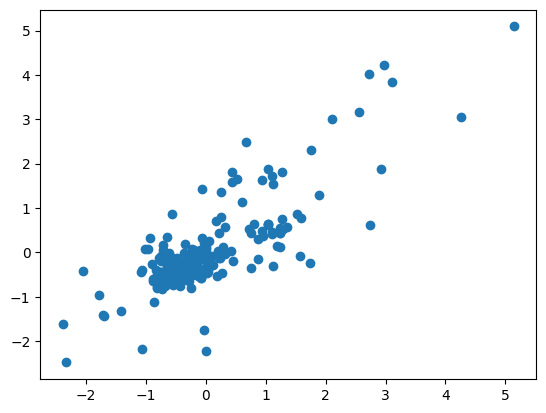

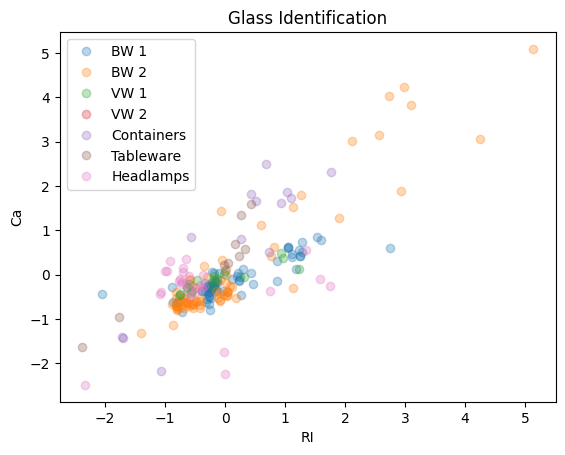

In [238]:
# Data attributes to be plotted
i = 0
j = 6

##
# Make a simple plot of the i'th attribute against the j'th attribute
plt.plot(X[:, i], X[:, j], "o")

##
# Make another more fancy plot that includes legend, class labels,
# attribute names, and a title.
f = plt.figure()
plt.title("Glass Identification")

for c in range(C):
    # select indices belonging to class c:
    class_mask = y == c+1
    plt.plot(X[class_mask, i], X[class_mask, j], "o", alpha=0.3, label=classNames[c])

plt.legend()
plt.xlabel(attributeNames[i])
plt.ylabel(attributeNames[j])

# Output result to screen
plt.show()


In [239]:
pd.DataFrame.corr(df)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000


In [240]:
corr_value = df['RI'].corr(df['Ca'])
corr_value

0.8104026963400852

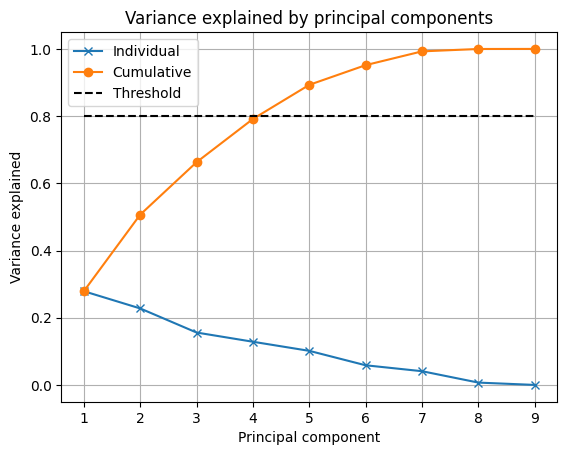

In [241]:
# Subtract mean value from data
# Note: Here we use Y to in teh book we often use X with a hat-symbol on top.
Y = X - np.ones((N, 1)) * X.mean(axis=0)

# PCA by computing SVD of Y
# Note: Here we call the Sigma matrix in the SVD S for notational convinience
U, S, Vh = svd(Y, full_matrices=False)

# scipy.linalg.svd returns "Vh", which is the Hermitian (transpose)
# of the vector V. So, for us to obtain the correct V, we transpose:
V = Vh.T

# Compute variance explained by principal components
# Note: This is an important equation, see Eq. 3.18 on page 40 in the book.
rho = (S * S) / (S * S).sum()

threshold = 0.80

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rho) + 1), rho, "x-")
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-")
plt.plot([1, len(rho)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()



First 4 principal components explain 80% of variance

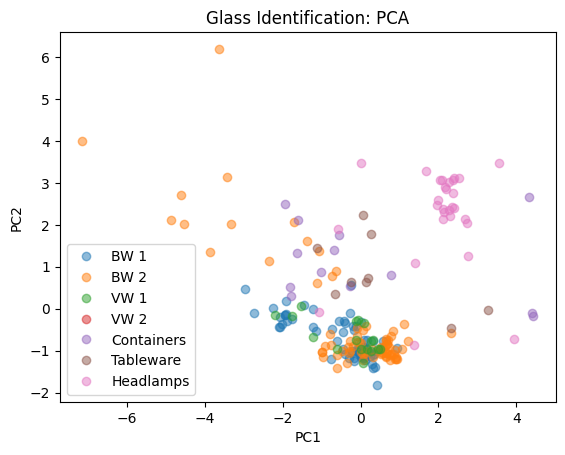

In [242]:
# Subtract mean value from data
Y = X - np.ones((N, 1)) * X.mean(0)

# PCA by computing SVD of Y
U, S, Vh = svd(Y, full_matrices=False)
# scipy.linalg.svd returns "Vh", which is the Hermitian (transpose)
# of the vector V. So, for us to obtain the correct V, we transpose:
V = Vh.T

# Project the centered data onto principal component space
# Note: Make absolutely sure you understand what the @ symbol
# does by inspecing the numpy documentation!
Z = Y @ V

# Indices of the principal components to be plotted
i = 0
j = 1

# Plot PCA of the data
f = plt.figure()
plt.title("Glass Identification: PCA")
# Z = array(Z)
for c in range(C):
    # select indices belonging to class c:
    class_mask = y == c+1
    plt.plot(Z[class_mask, i], Z[class_mask, j], "o", alpha=0.5)
plt.legend(classNames)
plt.xlabel("PC{0}".format(i + 1))
plt.ylabel("PC{0}".format(j + 1))

# Output result to screen
plt.show()

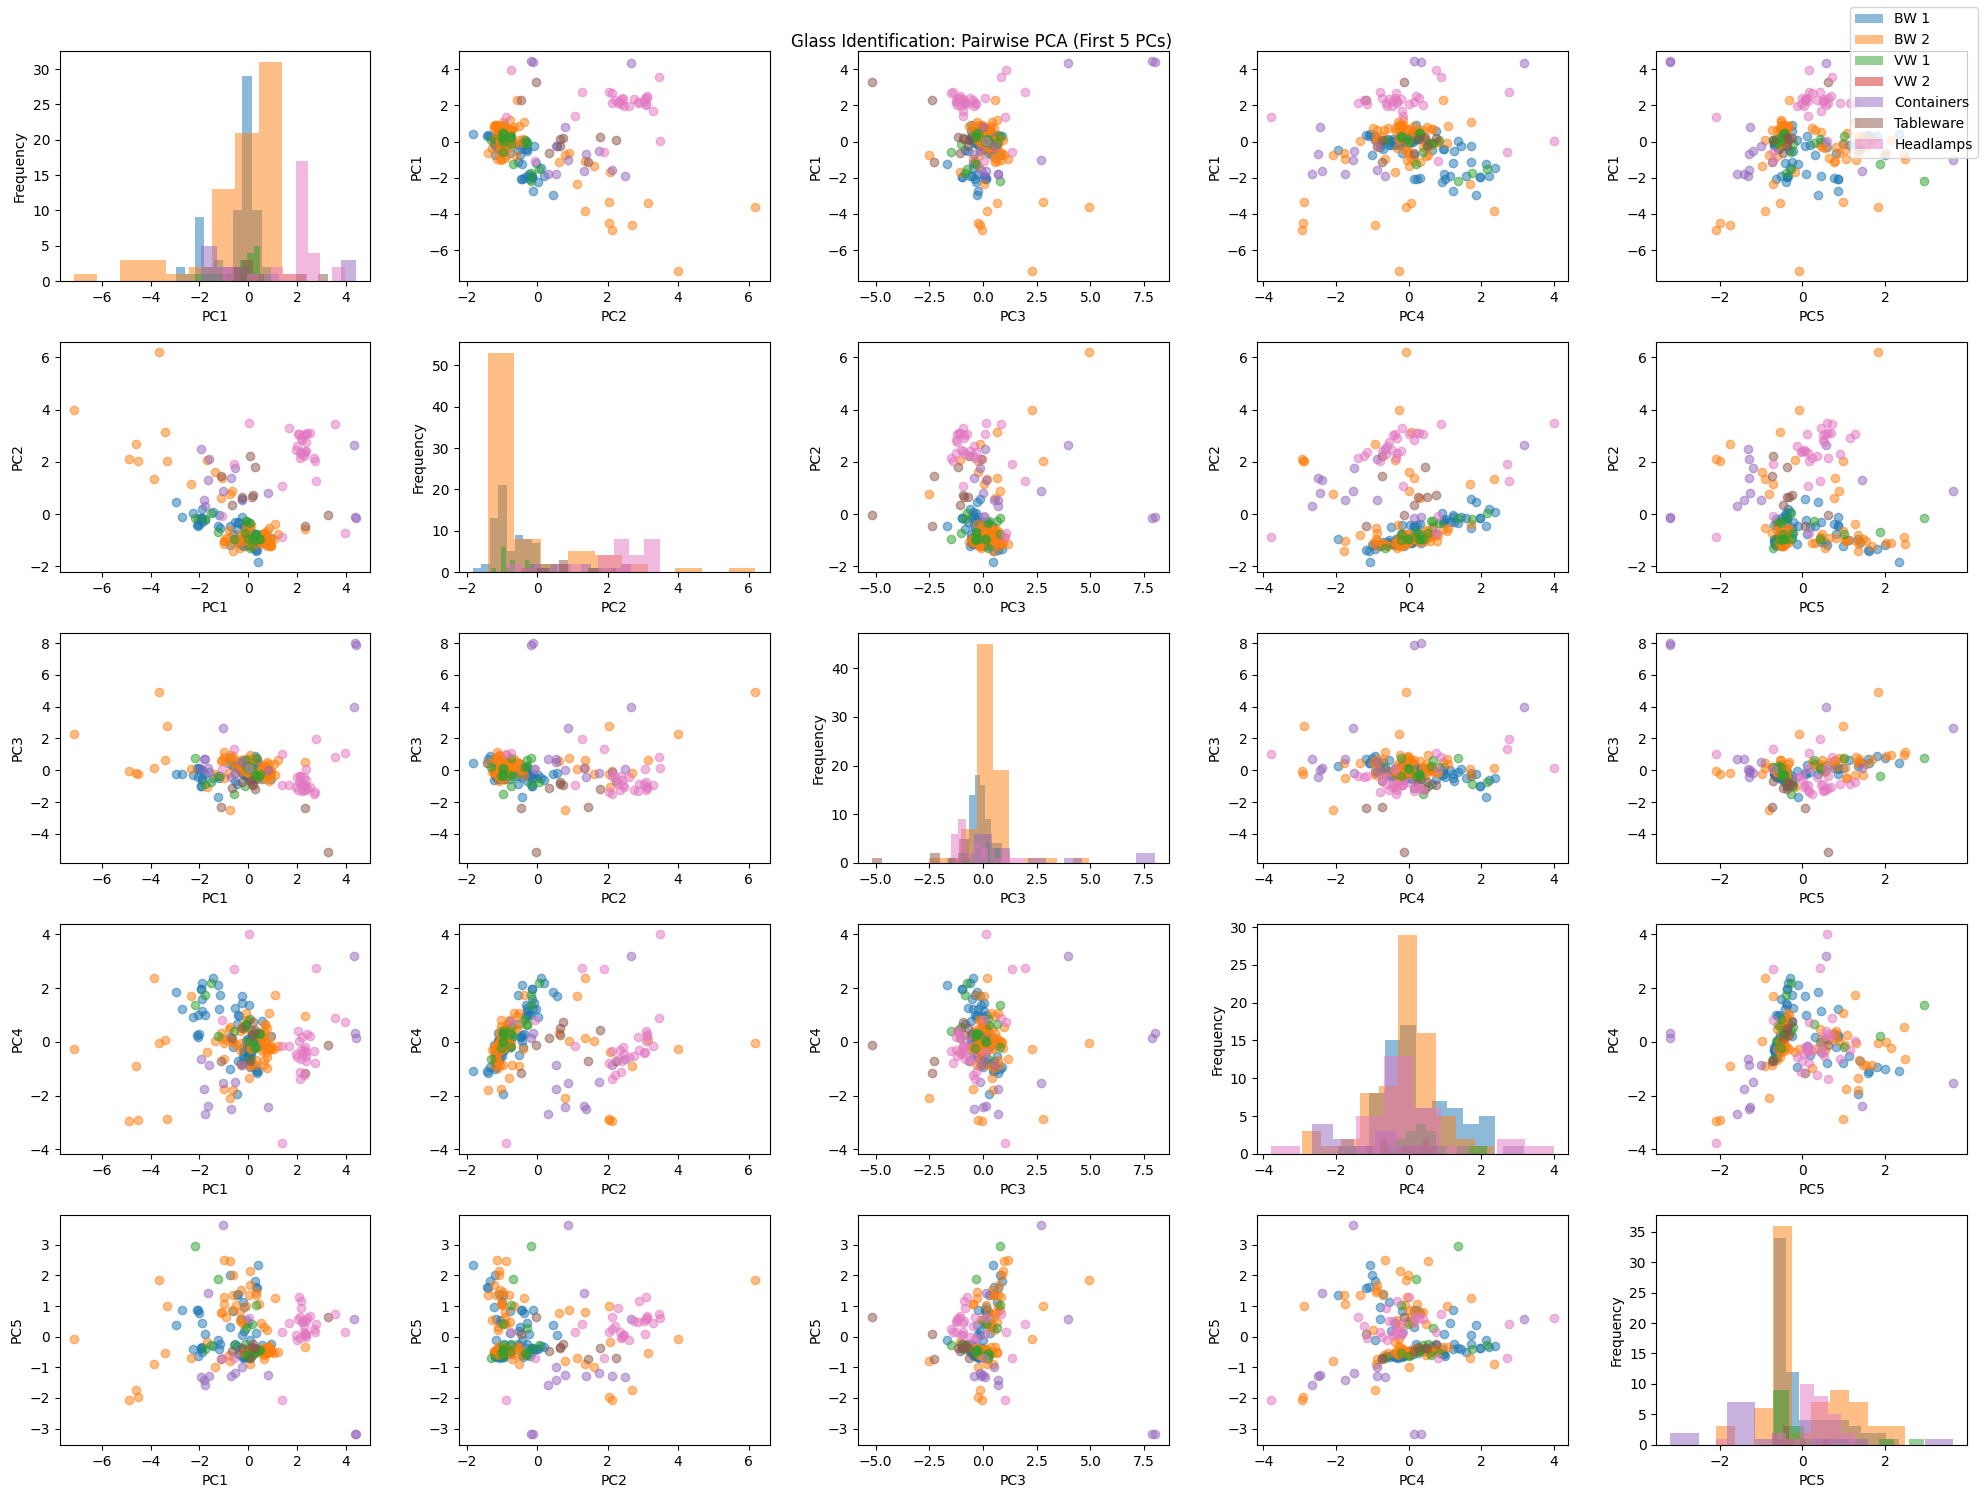

In [249]:
# Assuming X is your data matrix and y is the class labels
# N is the number of samples, and C is the number of classes
# classNames is a list of class names

# Subtract mean value from data
Y = X - np.ones((N, 1)) * X.mean(0)

# PCA by computing SVD of Y
U, S, Vh = svd(Y, full_matrices=False)
V = Vh.T

# Project the centered data onto principal component space
Z = Y @ V

# Number of principal components to plot (first 5 PCs)
num_pcs = 5

# Create a figure with subplots
f, axs = plt.subplots(num_pcs, num_pcs, figsize=(20, 15))
f.suptitle("Glass Identification: Pairwise PCA (First 5 PCs)")

# Loop through the first 5 principal components
# Loop through the first 5 principal components
for i in range(num_pcs):
    for j in range(num_pcs):
        if i == j:
            # Diagonal: histogram of PC values
            for c in range(C):
                class_mask = y == c + 1
                axs[i, j].hist(Z[class_mask, i], alpha=0.5, label=classNames[c])
            axs[i, j].set_xlabel(f"PC{i+1}")
            axs[i, j].set_ylabel("Frequency")
        else:
            # Off-diagonal: scatter plot of PC pairs
            for c in range(C):
                class_mask = y == c + 1
                axs[i, j].scatter(Z[class_mask, j], Z[class_mask, i], alpha=0.5, label=classNames[c])
            axs[i, j].set_xlabel(f"PC{j+1}")  # Fix label order
            axs[i, j].set_ylabel(f"PC{i+1}")  # Fix label order

# Add a single legend to the first subplot
handles, labels = axs[0, 0].get_legend_handles_labels()
f.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()

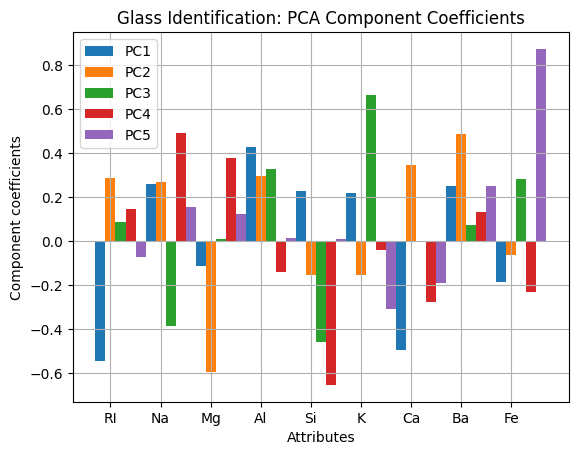

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
PC1,-0.545177,0.258126,-0.110881,0.428709,0.228836,0.219344,-0.492306,0.250375,-0.185842
PC2,0.285683,0.270350,-0.593558,0.295212,-0.155099,-0.153970,0.345380,0.484702,-0.062039
PC3,0.086911,-0.384920,0.008418,0.329237,-0.458709,0.662574,-0.000985,0.074055,0.284451
PC4,0.147381,0.491242,0.378786,-0.137506,-0.652538,-0.038535,-0.276443,0.133175,-0.230492
PC5,-0.073543,0.153683,0.123509,0.014109,0.008500,-0.307040,-0.188188,0.251334,0.873264


In [244]:
Y = X - np.ones((N, 1)) * X.mean(0)
U, S, Vh = svd(Y, full_matrices=False)
V = Vh.T
N, M = X.shape

# We saw in 2.1.3 that the first 3 components explaiend more than 90
# percent of the variance. Let's look at their coefficients:
pcs = [0, 1, 2 ,3, 4]
legendStrs = ["PC" + str(e + 1) for e in pcs]
bw = 0.2
r = np.arange(1, M + 1)

for i in pcs:
    plt.bar(r + i * bw, V[:, i], width=bw)

plt.xticks(r + bw, attributeNames)
plt.xlabel("Attributes")
plt.ylabel("Component coefficients")
plt.legend(legendStrs)
plt.grid()
plt.title("Glass Identification: PCA Component Coefficients")
plt.show()



pc_list = []
# Collect each principal component's coefficients
for c in range(len(pcs)):
    pc_list.append(V[:, c])
# Convert the list of principal components to a DataFrame
pc_df = pd.DataFrame(pc_list, columns=attributeNames)  # Assuming attributeNames is the list of feature names
pc_df.index = [f'PC{i+1}' for i in range(len(pcs))]
# Print the DataFrame
pc_df


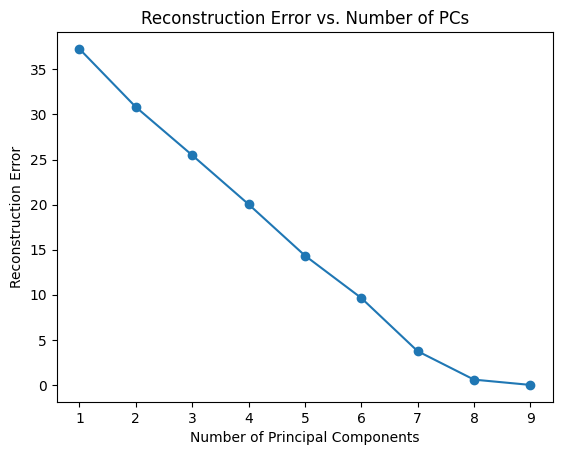

In [245]:
reconstruction_errors = []
for num_pcs in range(1, min(X.shape) + 1):
    Z_partial = Z[:, :num_pcs]
    V_partial = V[:, :num_pcs]
    X_reconstructed = (Z_partial @ V_partial.T) + X.mean(0)
    error = np.linalg.norm(X - X_reconstructed, ord="fro")  # Frobenius norm
    reconstruction_errors.append(error)

plt.figure()
plt.plot(range(1, min(X.shape) + 1), reconstruction_errors, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs. Number of PCs")
plt.show()
